In [23]:
from Bio import SeqIO
import pandas as pd

#loading the columns of the sars hum dataframe
df_sars_hum = pd.read_csv("/home/barth/python_project_linux/repo_copy/group04-team03/data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t", usecols=["pdb", "light_subclass"])
df_sars_hum['pdb'] = df_sars_hum['pdb'].str.lower().str.strip()
print(df_sars_hum.head())

    pdb light_subclass
0  8wu1          IGKV1
1  3lqa          IGLV1
2  4kxz          IGKV3
3  6vmk          IGKV1
4  6vmk          IGKV1


In [30]:
import numpy as np
import pandas as pd
#loading distance matrix 
dist_matrix = pd.read_csv("/home/barth/python_project_linux/repo_copy/group04-team03/blasting/mmseqs/distance_matrix.csv", index_col=0)

#consistent formating
dist_matrix.index = dist_matrix.index.str.strip()
dist_matrix.columns = dist_matrix.columns.str.strip()
pdb_id = df_sars_hum['pdb'].unique()
#creating a dataframe with merged distance matrix and gene families with the pdb-IDs 
#
def extract_pdb(full_id):
    # Assumes ID format like '1ADQ_entity2_chainL'
    return full_id.split('_')[0].lower()  # Lowercase to match pdb IDs like '8wu1'

# Apply to both rows and columns of distance matrix
dist_matrix.index = dist_matrix.index.map(extract_pdb)
dist_matrix.columns = dist_matrix.columns.map(extract_pdb)

df_sars_hum = df_sars_hum[df_sars_hum['pdb'].isin(dist_matrix.index)]
print(dist_matrix.shape)


matrix_pdb = sorted(set(dist_matrix.index).intersection(pdb_id))
dist_matrix = dist_matrix.loc[matrix_pdb, matrix_pdb]
dist_matrix.to_csv("distance_matrix_light_subclass.csv")
print(dist_matrix.head)


(1013, 1013)
<bound method NDFrame.head of        1adq   1h0d   1i9r   1iqd   1jps   1uj3   1w72   2b4c   2fjh   2j6e  \
1adq  0.000  1.000  1.000  1.000  1.000  1.000  0.044  1.000  1.000  0.226   
1h0d  1.000  0.000  0.349  1.000  1.000  1.000  1.000  0.413  0.395  1.000   
1i9r  1.000  0.349  0.000  1.000  0.179  0.184  1.000  1.000  0.156  1.000   
1iqd  1.000  1.000  1.000  0.000  0.185  1.000  1.000  0.072  0.162  1.000   
1jps  1.000  1.000  0.179  0.185  0.000  0.043  1.000  0.196  0.080  1.000   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
9j66  1.000  0.418  0.175  0.190  0.099  0.103  1.000  0.196  0.066  1.000   
9l6c  1.000  1.000  1.000  0.102  1.000  1.000  1.000  0.111  1.000  1.000   
9l6c  1.000  1.000  1.000  1.000  0.176  1.000  1.000  1.000  0.139  1.000   
9l6c  1.000  1.000  1.000  0.075  1.000  1.000  1.000  0.084  1.000  1.000   
9mi6  0.215  1.000  1.000  1.000  1.000  1.000  0.239  1.000  1.000  0.209   

      ...   9dh2   9

/home/barth/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


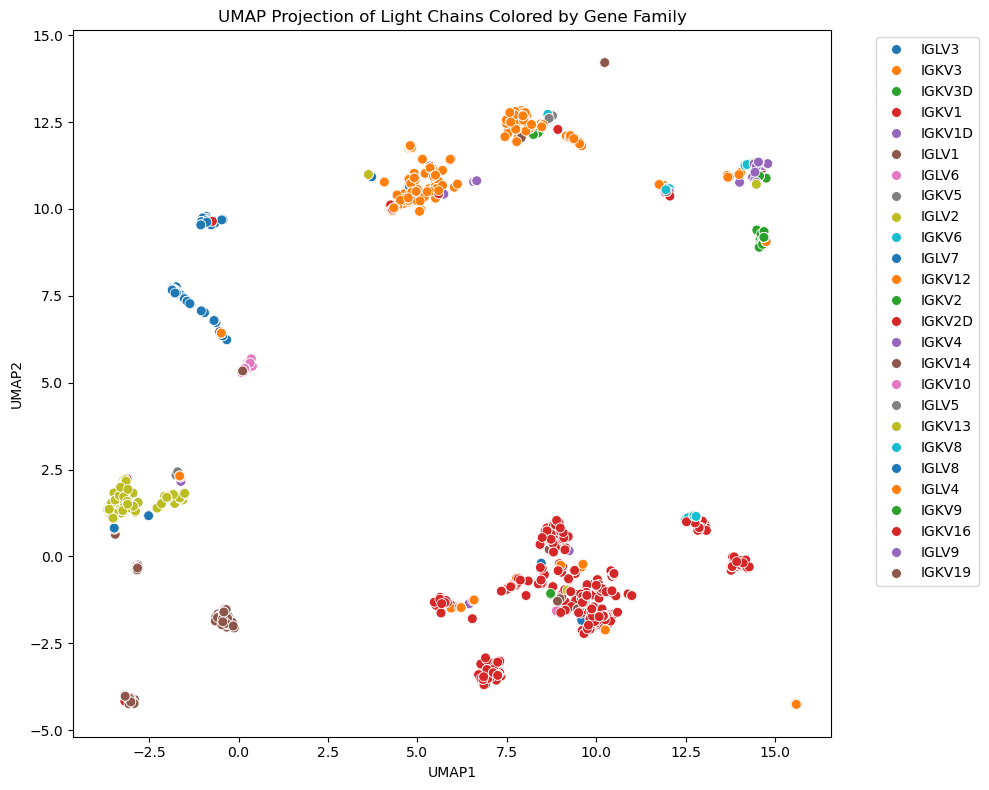

In [32]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# UMAP expects an array of shape (n_samples, n_features)
# Since this is a distance matrix, we set `metric="precomputed"`
reducer = umap.UMAP(metric='precomputed', random_state=42)
embedding = reducer.fit_transform(dist_matrix)

# Merge with annotations
df_umap = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
df_umap["pdb"] = dist_matrix.index
df_umap = df_umap.merge(df_sars_hum, on="pdb", how="left")

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="light_subclass", palette="tab10", s=50)
plt.title("UMAP Projection of Light Chains Colored by Gene Family")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()